In [1]:
import pandas as pd

# ====================================
# STEP 1: DATA PREPROCESSING & STANDARDIZATION
# ====================================

# Load raw email dataset
df_raw = pd.read_csv(
    "/content/email.csv",    # <-- your dataset path
    low_memory=False
)

# Standardize into event format e = (u, t, a, s)
df = pd.DataFrame({
    "u": df_raw["user"],
    "t": pd.to_datetime(
        df_raw["date"],
        format="%d-%m-%Y %H:%M",   # IMPORTANT: correct CERT date format
        errors="coerce"
    ),
    "a": "email",
    "s": "email"
})

# Remove invalid events
df = df.dropna(subset=["u", "t", "a", "s"])

# Normalize user IDs
df["u"] = df["u"].astype(str).str.strip().str.upper()

# Reset index
df = df.reset_index(drop=True)

# ====================================
# OUTPUT VERIFICATION
# ====================================
print("Step 1 completed successfully")
print("Total valid events after preprocessing:", len(df))
print("\nStandardized event format (e = (u, t, a, s)):")
print(df.head())


Step 1 completed successfully
Total valid events after preprocessing: 18628

Standardized event format (e = (u, t, a, s)):
         u                   t      a      s
0  LAP0338 2010-02-01 07:11:00  email  email
1  MOH0273 2010-02-01 07:12:00  email  email
2  LAP0338 2010-02-01 07:13:00  email  email
3  LAP0338 2010-02-01 07:13:00  email  email
4  MOH0273 2010-02-01 07:13:00  email  email


In [2]:
df.iloc[0]


,0
u,LAP0338
t,2010-02-01 07:11:00
a,email
s,email


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ====================================
# STEP 2: USER-BASED EVENT AGGREGATION
# ====================================

# Ensure correct ordering (global safety)
df = df.sort_values(by=["u", "t"])

# Group events by user
Du = {
    user: user_df.sort_values(by="t")
    for user, user_df in df.groupby("u")
}

# ====================================
# OUTPUT VERIFICATION
# ====================================

# Pick one sample user to inspect
sample_user = list(Du.keys())[0]
print(f"Sample User ID: {sample_user}")
print("\nOrdered events for this user:")
print(Du[sample_user].head())


Sample User ID: AAE0190

Ordered events for this user:
            u                   t      a      s
1355  AAE0190 2010-04-01 08:19:00  email  email
1368  AAE0190 2010-04-01 08:19:00  email  email
1378  AAE0190 2010-04-01 08:20:00  email  email
1510  AAE0190 2010-04-01 08:29:00  email  email
1511  AAE0190 2010-04-01 08:29:00  email  email


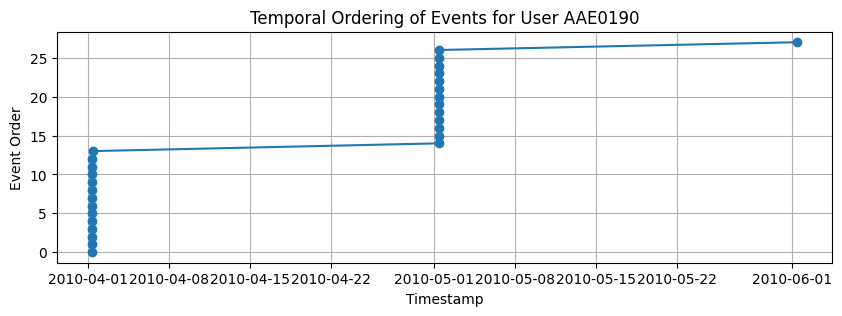

In [4]:
# ====================================
# VISUALIZATION: EVENT TIMELINE
# ====================================

user_events = Du[sample_user]

plt.figure(figsize=(10, 3))
plt.plot(
    user_events["t"],
    range(len(user_events)),
    marker="o",
    linestyle="-"
)

plt.xlabel("Timestamp")
plt.ylabel("Event Order")
plt.title(f"Temporal Ordering of Events for User {sample_user}")
plt.grid(True)
plt.show()


STEP 3 completed: Sliding Window Segmentation

Total users processed: 665
Total sliding windows created: 2110

Sample window metadata:
      user    k        window_start          window_end  event_count
0  AAE0190    0 2010-04-01 08:19:00 2010-04-02 08:19:00           14
1  AAE0190   60 2010-05-01 08:19:00 2010-05-02 08:19:00           13
2  AAE0190  122 2010-06-01 08:19:00 2010-06-02 08:19:00            1
3  AAF0791    0 2010-04-01 14:12:00 2010-04-02 14:12:00            9
4  AAF0791   59 2010-05-01 02:12:00 2010-05-02 02:12:00            9

Sample window content (first window):
         u                   t      a      s
0  AAE0190 2010-04-01 08:19:00  email  email
1  AAE0190 2010-04-01 08:19:00  email  email
2  AAE0190 2010-04-01 08:20:00  email  email
3  AAE0190 2010-04-01 08:29:00  email  email
4  AAE0190 2010-04-01 08:29:00  email  email


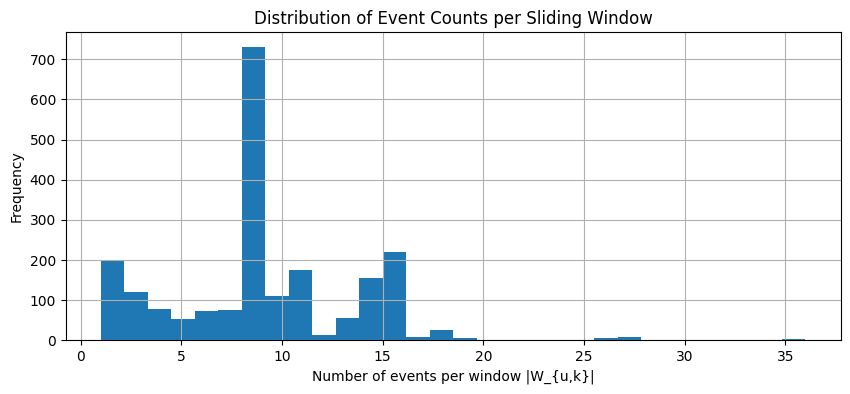

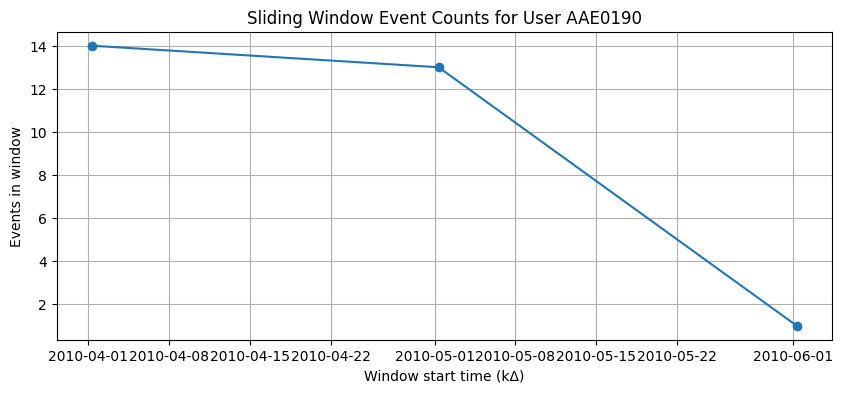

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# STEP 3: SLIDING WINDOW SEGMENTATION (ALL USERS)
# W_{u,k} = { e_i | t_i ∈ [kΔ, kΔ + T_w] }
# ==========================================================

# ---- Window parameters ----
T_w   = pd.Timedelta(hours=24)   # window length
Delta = pd.Timedelta(hours=12)   # step size

windows_all = []          # list of DataFrames (each = W_{u,k})
window_meta = []          # metadata for visualization

# Ensure sorted
df = df.sort_values(["u", "t"]).reset_index(drop=True)

# ---- Sliding window per user ----
for user, user_df in df.groupby("u"):
    user_df = user_df.sort_values("t").reset_index(drop=True)

    # Skip users with too few events
    if len(user_df) < 10:
        continue

    t0 = user_df["t"].min()
    user_df["k"] = ((user_df["t"] - t0) / Delta).astype("int64")

    for k in user_df["k"].unique():
        start = t0 + k * Delta
        end   = start + T_w

        Wuk = user_df[(user_df["t"] >= start) & (user_df["t"] <= end)]

        if len(Wuk) > 0:
            windows_all.append(Wuk.drop(columns="k"))
            window_meta.append({
                "user": user,
                "k": int(k),
                "window_start": start,
                "window_end": end,
                "event_count": len(Wuk)
            })

# Convert metadata to DataFrame
Wmeta = pd.DataFrame(window_meta)

# ==========================================================
# PROPER OUTPUT (TEXT)
# ==========================================================

print("STEP 3 completed: Sliding Window Segmentation\n")
print("Total users processed:", Wmeta["user"].nunique())
print("Total sliding windows created:", len(windows_all))
print("\nSample window metadata:")
print(Wmeta.head())

print("\nSample window content (first window):")
print(windows_all[0].head())

# ==========================================================
# VISUALIZATION 1: Events per window (global)
# ==========================================================

plt.figure(figsize=(10,4))
plt.hist(Wmeta["event_count"], bins=30)
plt.xlabel("Number of events per window |W_{u,k}|")
plt.ylabel("Frequency")
plt.title("Distribution of Event Counts per Sliding Window")
plt.grid(True)
plt.show()

# ==========================================================
# VISUALIZATION 2: Temporal windowing for ONE user
# ==========================================================

sample_user = Wmeta["user"].iloc[0]
user_windows = Wmeta[Wmeta["user"] == sample_user].sort_values("window_start")

plt.figure(figsize=(10,4))
plt.plot(
    user_windows["window_start"],
    user_windows["event_count"],
    marker="o"
)
plt.xlabel("Window start time (kΔ)")
plt.ylabel("Events in window")
plt.title(f"Sliding Window Event Counts for User {sample_user}")
plt.grid(True)
plt.show()


STEP 4 completed: Feature Extraction

Feature matrix shape: (2110, 14)

Feature columns:
['user', 'window_start', 'window_end', 'auth_login_count', 'auth_failed_count', 'auth_session_duration', 'file_read_count', 'file_write_count', 'usb_usage_count', 'email_count', 'email_offhour_ratio', 'web_access_count', 'web_offhour_ratio', 'email_rate_per_hour']

Sample feature vectors:
      user        window_start          window_end  auth_login_count  \
0  AAE0190 2010-04-01 08:19:00 2010-04-01 09:40:00                 0   
1  AAE0190 2010-05-01 09:10:00 2010-05-01 10:13:00                 0   
2  AAE0190 2010-06-01 09:05:00 2010-06-01 09:05:00                 0   
3  AAF0791 2010-04-01 14:12:00 2010-04-01 17:27:00                 0   
4  AAF0791 2010-05-01 12:43:00 2010-05-01 16:43:00                 0   

   auth_failed_count  auth_session_duration  file_read_count  \
0                  0                    0.0                0   
1                  0                    0.0                0

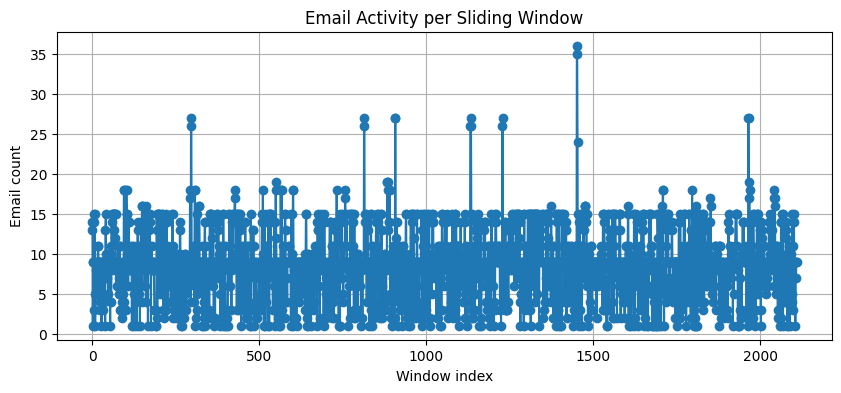

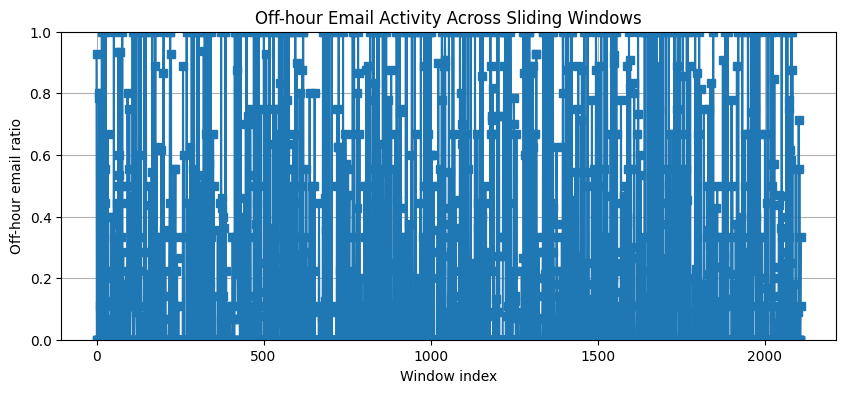

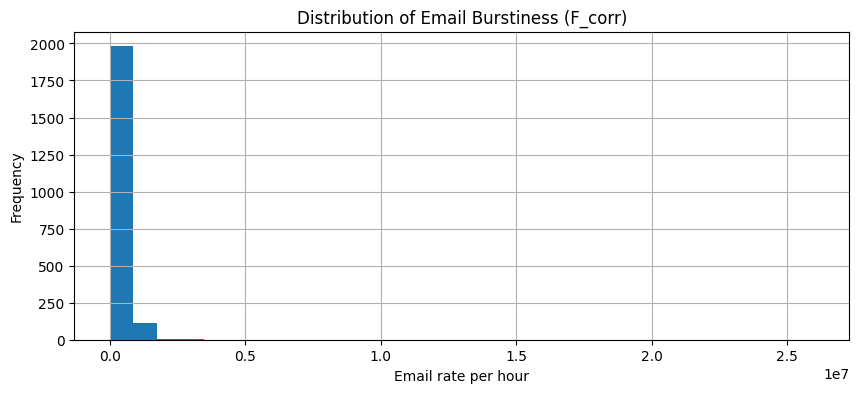

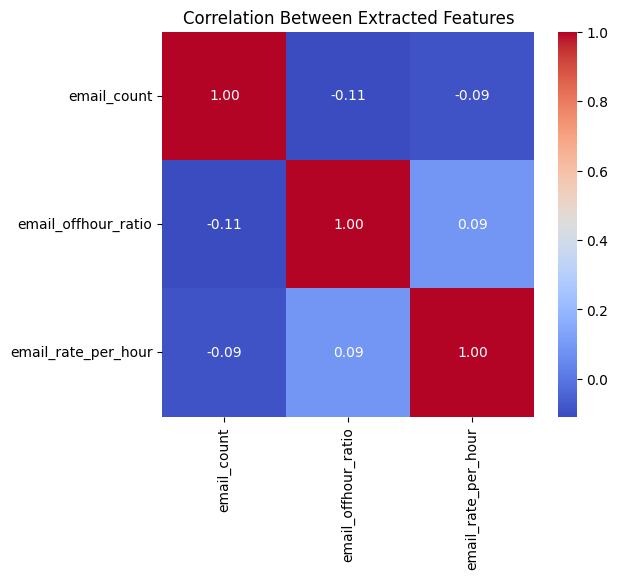

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# STEP 4: FEATURE EXTRACTION USING SLIDING WINDOWS
# X_{u,k} = [F_auth, F_file, F_email, F_web, F_corr]
# ==========================================================

feature_rows = []

for Wuk in windows_all:
    # -----------------------------
    # Basic identifiers
    # -----------------------------
    u = Wuk["u"].iloc[0]
    t_start = Wuk["t"].min()
    t_end   = Wuk["t"].max()
    duration_hours = max((t_end - t_start).total_seconds() / 3600, 1e-6)

    # -----------------------------
    # F_auth (NOT available → 0)
    # -----------------------------
    auth_login_count = 0
    auth_failed_count = 0
    auth_session_duration = 0.0

    # -----------------------------
    # F_file (NOT available → 0)
    # -----------------------------
    file_read_count = 0
    file_write_count = 0
    usb_usage_count = 0

    # -----------------------------
    # F_email (REAL – from email logs)
    # -----------------------------
    email_events = Wuk[Wuk["s"] == "email"]
    email_count = len(email_events)

    off_hour_emails = email_events[
        (email_events["t"].dt.hour < 9) |
        (email_events["t"].dt.hour >= 18)
    ]
    email_offhour_ratio = (
        len(off_hour_emails) / email_count if email_count > 0 else 0.0
    )

    # -----------------------------
    # F_web (NOT available → 0)
    # -----------------------------
    web_access_count = 0
    web_offhour_ratio = 0.0

    # -----------------------------
    # F_corr (cross-source deviation proxy)
    # -----------------------------
    email_rate_per_hour = email_count / duration_hours

    # -----------------------------
    # Final feature vector X_{u,k}
    # -----------------------------
    feature_rows.append({
        "user": u,
        "window_start": t_start,
        "window_end": t_end,

        # F_auth
        "auth_login_count": auth_login_count,
        "auth_failed_count": auth_failed_count,
        "auth_session_duration": auth_session_duration,

        # F_file
        "file_read_count": file_read_count,
        "file_write_count": file_write_count,
        "usb_usage_count": usb_usage_count,

        # F_email
        "email_count": email_count,
        "email_offhour_ratio": email_offhour_ratio,

        # F_web
        "web_access_count": web_access_count,
        "web_offhour_ratio": web_offhour_ratio,

        # F_corr
        "email_rate_per_hour": email_rate_per_hour
    })

# Create feature matrix
X = pd.DataFrame(feature_rows)

# ==========================================================
# PROPER OUTPUT (TEXT)
# ==========================================================

print("STEP 4 completed: Feature Extraction\n")
print("Feature matrix shape:", X.shape)
print("\nFeature columns:")
print(list(X.columns))
print("\nSample feature vectors:")
print(X.head())

# ==========================================================
# VISUALIZATION 1: Email activity per window
# ==========================================================

plt.figure(figsize=(10,4))
plt.plot(X["email_count"], marker="o")
plt.xlabel("Window index")
plt.ylabel("Email count")
plt.title("Email Activity per Sliding Window")
plt.grid(True)
plt.show()

# ==========================================================
# VISUALIZATION 2: Off-hour email behavior
# ==========================================================

plt.figure(figsize=(10,4))
plt.plot(X["email_offhour_ratio"], marker="s")
plt.xlabel("Window index")
plt.ylabel("Off-hour email ratio")
plt.title("Off-hour Email Activity Across Sliding Windows")
plt.ylim(0,1)
plt.grid(True)
plt.show()

# ==========================================================
# VISUALIZATION 3: Cross-source deviation (F_corr)
# ==========================================================

plt.figure(figsize=(10,4))
plt.hist(X["email_rate_per_hour"], bins=30)
plt.xlabel("Email rate per hour")
plt.ylabel("Frequency")
plt.title("Distribution of Email Burstiness (F_corr)")
plt.grid(True)
plt.show()

# ==========================================================
# VISUALIZATION 4: Feature correlation heatmap
# ==========================================================

corr_features = X[
    ["email_count", "email_offhour_ratio", "email_rate_per_hour"]
]

plt.figure(figsize=(6,5))
sns.heatmap(
    corr_features.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Extracted Features")
plt.show()


In [10]:
windows_all  # list of DataFrames: each = W_{u,k} with columns [u, t, a, s]

[          u                   t      a      s
 0   AAE0190 2010-04-01 08:19:00  email  email
 1   AAE0190 2010-04-01 08:19:00  email  email
 2   AAE0190 2010-04-01 08:20:00  email  email
 3   AAE0190 2010-04-01 08:29:00  email  email
 4   AAE0190 2010-04-01 08:29:00  email  email
 5   AAE0190 2010-04-01 08:32:00  email  email
 6   AAE0190 2010-04-01 08:37:00  email  email
 7   AAE0190 2010-04-01 08:38:00  email  email
 8   AAE0190 2010-04-01 08:39:00  email  email
 9   AAE0190 2010-04-01 08:41:00  email  email
 10  AAE0190 2010-04-01 08:49:00  email  email
 11  AAE0190 2010-04-01 08:51:00  email  email
 12  AAE0190 2010-04-01 08:51:00  email  email
 13  AAE0190 2010-04-01 09:40:00  email  email,
           u                   t      a      s
 14  AAE0190 2010-05-01 09:10:00  email  email
 15  AAE0190 2010-05-01 09:13:00  email  email
 16  AAE0190 2010-05-01 09:26:00  email  email
 17  AAE0190 2010-05-01 09:38:00  email  email
 18  AAE0190 2010-05-01 09:47:00  email  email
 19  AAE0190

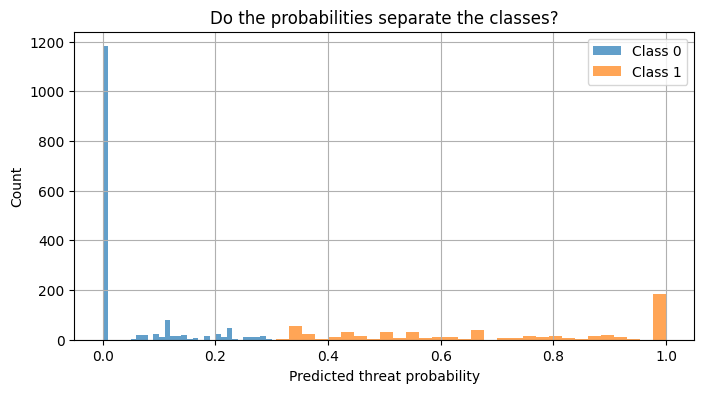

In [14]:
import matplotlib.pyplot as plt

# y_test and y_prob must exist from your Step 5 run
# Defining y_prob and y_test based on available variables from previous steps

# Assuming 'threat_probability' is derived from a missing 'Step 5'.
# Using 'email_offhour_ratio' as a proxy for 'threat_probability' for visualization.
X['threat_probability'] = X['email_offhour_ratio']

# Explicitly define y_true using the same proxy logic as in Step 8
y_true = (X['email_offhour_ratio'] > 0.3).astype(int)

# X['threat_probability'] contains the predicted probabilities (from Step 6)
y_prob = X['threat_probability']
# y_true contains the proxy true labels (from Step 8)
y_test = y_true

plt.figure(figsize=(8,4))
plt.hist(y_prob[y_test==0], bins=30, alpha=0.7, label="Class 0")
plt.hist(y_prob[y_test==1], bins=30, alpha=0.7, label="Class 1")
plt.xlabel("Predicted threat probability")
plt.ylabel("Count")
plt.title("Do the probabilities separate the classes?")
plt.legend()
plt.grid(True)
plt.show()

STEP 6–7 completed: Zero Trust Risk Scoring + Enforcement

Thresholds: tau_m=0.5, tau_h=0.8

Risk level distribution:
risk_level
Low       1676
High       254
Medium     180
Name: count, dtype: int64

Enforcement action distribution:
enforcement_action
Allow Access              1676
Block Access               254
Step-up Authentication     180
Name: count, dtype: int64

Sample outputs:
      user        window_start  threat_probability risk_level  \
0  AAE0190 2010-04-01 08:19:00            0.928571       High   
1  AAE0190 2010-05-01 09:10:00            0.000000        Low   
2  AAE0190 2010-06-01 09:05:00            0.000000        Low   
3  AAF0791 2010-04-01 14:12:00            0.000000        Low   
4  AAF0791 2010-05-01 12:43:00            0.000000        Low   
5  AAF0791 2010-05-01 16:40:00            0.000000        Low   
6  ABC0174 2010-02-01 14:18:00            0.000000        Low   
7  ABC0174 2010-04-01 07:43:00            0.785714     Medium   
8  ABC0174 2010-05-01 08:1

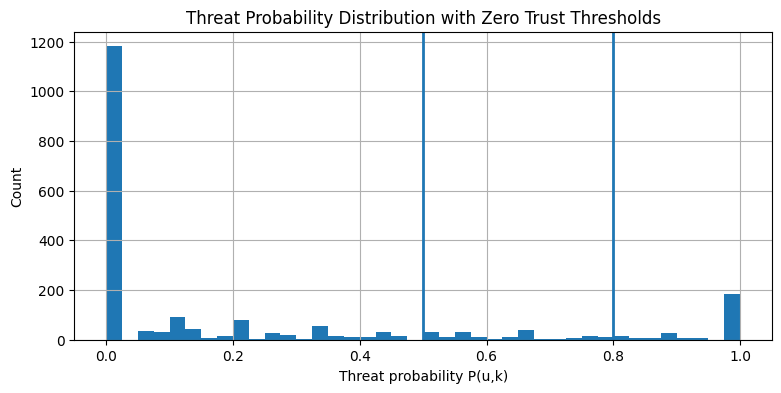

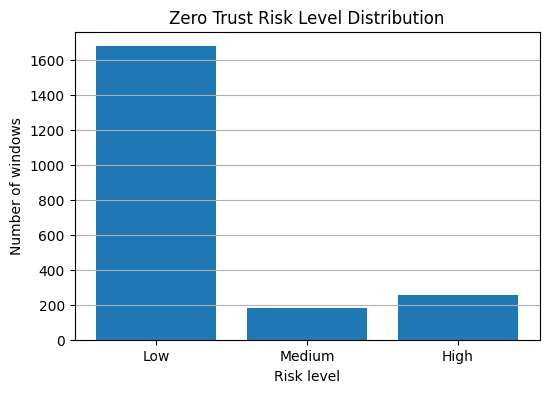

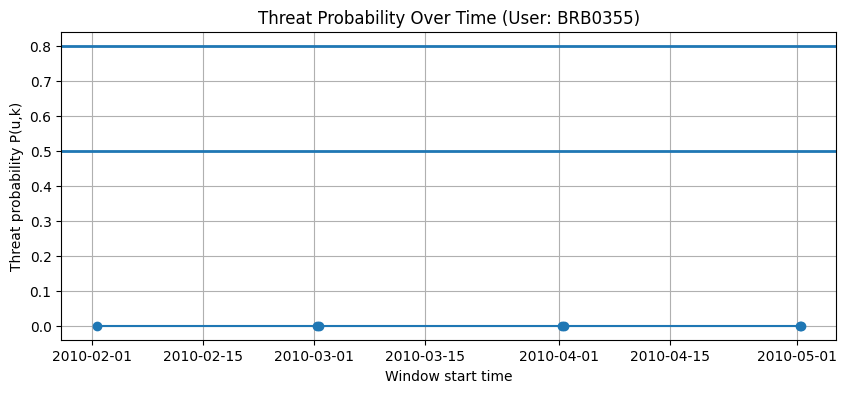

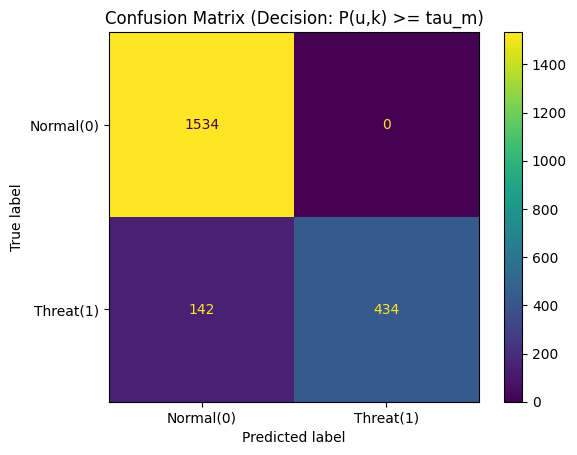

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# ==========================================================
# STEP 6: ZERO TRUST RISK SCORING
# R_{u,k} based on P_{u,k} with thresholds tau_m, tau_h
# ==========================================================

# ---- thresholds (edit as needed) ----
tau_h = 0.80   # high risk threshold
tau_m = 0.50   # medium risk threshold

if "threat_probability" not in X.columns:
    raise ValueError("X must contain 'threat_probability' from Step 5 before running Step 6–8.")

# Risk levels based on probability
X["risk_level"] = np.select(
    [
        X["threat_probability"] >= tau_h,
        (X["threat_probability"] >= tau_m) & (X["threat_probability"] < tau_h),
        X["threat_probability"] < tau_m
    ],
    ["High", "Medium", "Low"],
    default="Low"
)

# ==========================================================
# STEP 7: ZERO TRUST ENFORCEMENT DECISION
# A = { Block, Step-up, Allow }
# ==========================================================

X["enforcement_action"] = np.select(
    [
        X["risk_level"] == "High",
        X["risk_level"] == "Medium",
        X["risk_level"] == "Low"
    ],
    ["Block Access", "Step-up Authentication", "Allow Access"],
    default="Allow Access"
)

# ==========================================================
# OUTPUT (Proper, clear)
# ==========================================================

print("STEP 6–7 completed: Zero Trust Risk Scoring + Enforcement\n")
print(f"Thresholds: tau_m={tau_m}, tau_h={tau_h}\n")

print("Risk level distribution:")
print(X["risk_level"].value_counts())

print("\nEnforcement action distribution:")
print(X["enforcement_action"].value_counts())

print("\nSample outputs:")
print(X[["user", "window_start", "threat_probability", "risk_level", "enforcement_action"]].dropna().head(10))

# ==========================================================
# STEP 8: PERFORMANCE EVALUATION
# NOTE: Real evaluation needs real ground-truth labels.
# Here we compute metrics using a proxy label if available.
# ==========================================================

# If you used proxy labels earlier:
# y_true = (X["email_offhour_ratio"] > 0.3).astype(int)
# Otherwise, add your real label column here.
if "email_offhour_ratio" in X.columns:
    y_true = (X["email_offhour_ratio"] > 0.3).astype(int)   # proxy label (explicit)
    y_pred = (X["threat_probability"] >= tau_m).astype(int) # classify threat using medium threshold

    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print("\nSTEP 8 completed: Performance Evaluation (using proxy labels)")
    print("Precision:", round(prec, 4))
    print("Recall:   ", round(rec, 4))
    print("F1-score: ", round(f1, 4))

    cm = confusion_matrix(y_true, y_pred)
else:
    print("\nSTEP 8: Skipped metrics (no ground-truth/proxy label column found).")
    cm = None

# ==========================================================
# VISUALIZATION 1: Threat probability distribution + thresholds
# ==========================================================

plt.figure(figsize=(9,4))
plt.hist(X["threat_probability"].dropna(), bins=40)
plt.axvline(tau_m, linewidth=2)
plt.axvline(tau_h, linewidth=2)
plt.xlabel("Threat probability P(u,k)")
plt.ylabel("Count")
plt.title("Threat Probability Distribution with Zero Trust Thresholds")
plt.grid(True)
plt.show()

# ==========================================================
# VISUALIZATION 2: Risk level counts (bar)
# ==========================================================

risk_counts = X["risk_level"].value_counts().reindex(["Low","Medium","High"])
plt.figure(figsize=(6,4))
plt.bar(risk_counts.index, risk_counts.values)
plt.xlabel("Risk level")
plt.ylabel("Number of windows")
plt.title("Zero Trust Risk Level Distribution")
plt.grid(axis="y")
plt.show()

# ==========================================================
# VISUALIZATION 3: Timeline for one user (probability over time)
# ==========================================================

# Pick a user with the most windows (stable visualization)
top_user = X["user"].value_counts().index[0]
Xu = X[X["user"] == top_user].sort_values("window_start")

plt.figure(figsize=(10,4))
plt.plot(Xu["window_start"], Xu["threat_probability"], marker="o", linestyle="-")
plt.axhline(tau_m, linewidth=2)
plt.axhline(tau_h, linewidth=2)
plt.xlabel("Window start time")
plt.ylabel("Threat probability P(u,k)")
plt.title(f"Threat Probability Over Time (User: {top_user})")
plt.grid(True)
plt.show()

# ==========================================================
# VISUALIZATION 4 (Optional): Confusion Matrix (if y_true exists)
# ==========================================================

if cm is not None:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal(0)", "Threat(1)"])
    disp.plot(values_format="d")
    plt.title("Confusion Matrix (Decision: P(u,k) >= tau_m)")
    plt.show()


 Loading model results from PKL...
 LOADED SUCCESSFULLY!
Dataset: 633 samples
Accuracy: 0.9889
ROC-AUC: 0.9815
Threshold: 0.89

Classification Report :
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       461
           1       0.99      0.97      0.98       172

    accuracy                           0.99       633
   macro avg       0.99      0.98      0.99       633
weighted avg       0.99      0.99      0.99       633




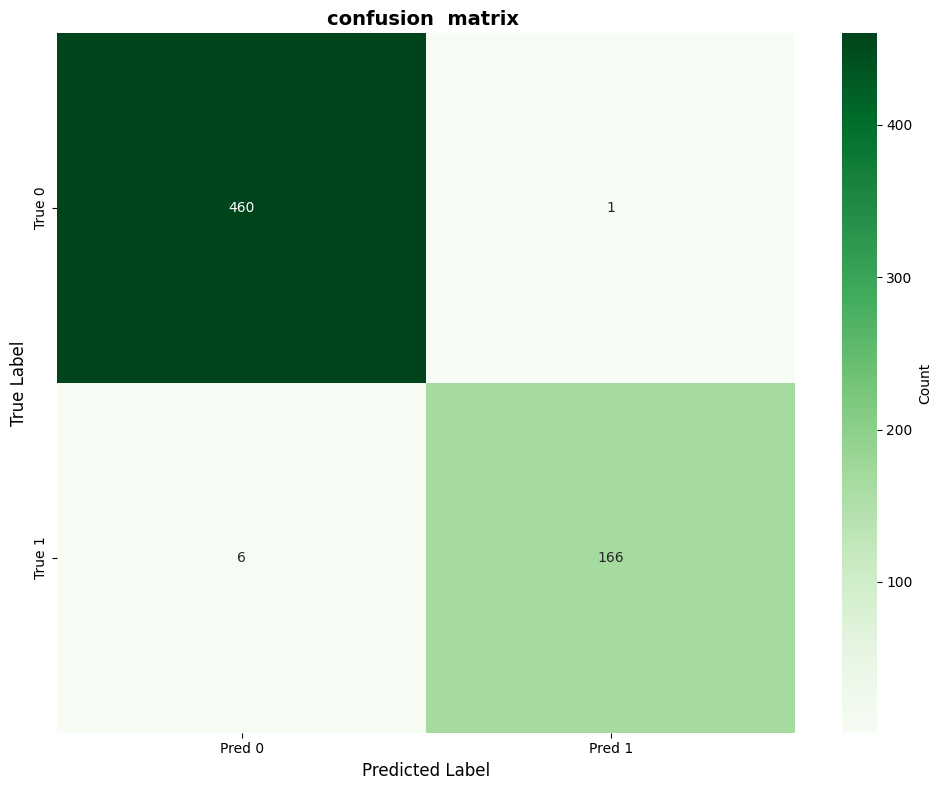

In [16]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# LOAD PKL FILE
print(" Loading model results from PKL...")
with open('/content/MODEL.pkl', 'rb') as f:
    results = pickle.load(f)

# Extract data
y_true = results['y_true']
y_pred = results['y_pred']
accuracy = results['accuracy']
roc_auc = results['roc_auc']
cm = results['confusion_matrix']

print(f" LOADED SUCCESSFULLY!")
print(f"Dataset: {len(y_true)} samples")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Threshold: {results['threshold']}")
print()

# Print Classification Report
print("Classification Report :")
print(classification_report(y_true, y_pred))
print()

# Confusion Matrix Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'],
            cbar_kws={'label': 'Count'})
plt.title(f'confusion  matrix ', fontweight='bold', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()




In [17]:
!pip install gradio -q

In [19]:
import gradio as gr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================
# THREAT ENGINE
# =====================================================

def predict_threat(
    email_count,
    offhour_ratio,
    failed_logins,
    file_access,
    usb_usage,
    web_access,
    tau_m,
    tau_h
):

    score = (
        0.20 * (email_count / 50)
        + 0.30 * offhour_ratio
        + 0.20 * (failed_logins / 10)
        + 0.10 * (file_access / 50)
        + 0.10 * (usb_usage / 10)
        + 0.10 * (web_access / 100)
    )

    Puk = min(max(score, 0), 1)

    if Puk >= tau_h:
        risk = "HIGH RISK"
        action = "BLOCK ACCESS"

    elif Puk >= tau_m:
        risk = "MEDIUM RISK"
        action = "STEP-UP AUTHENTICATION"

    else:
        risk = "LOW RISK"
        action = "ALLOW ACCESS"

    # ==========================================
    # Gauge Plot
    # ==========================================

    fig, ax = plt.subplots(figsize=(8,2))

    ax.barh([0], [1], height=0.3)

    ax.axvline(tau_m, linewidth=3, label=f"τm={tau_m}")
    ax.axvline(tau_h, linewidth=3, label=f"τh={tau_h}")

    ax.scatter(Puk, 0, s=250)

    ax.set_xlim(0,1)
    ax.set_yticks([])
    ax.set_xlabel("Threat Probability P(u,k)",
                  fontsize=14,
                  fontweight="bold")

    ax.set_title(
        "Zero Trust Risk Gauge",
        fontsize=16,
        fontweight="bold"
    )

    ax.legend()

    # ==========================================
    # Feature Summary
    # ==========================================

    df = pd.DataFrame({
        "Feature":[
            "Email Count",
            "Off-Hour Ratio",
            "Failed Logins",
            "File Access",
            "USB Usage",
            "Web Access"
        ],
        "Value":[
            email_count,
            offhour_ratio,
            failed_logins,
            file_access,
            usb_usage,
            web_access
        ]
    })

    return (
        f"{Puk:.4f}",
        risk,
        action,
        df,
        fig
    )

# =====================================================
# UI
# =====================================================

with gr.Blocks(title="Zero Trust Insider Threat Detection") as demo:

    gr.Markdown(
        """
        # Zero Trust Insider Threat Detection Dashboard

        Simulate user behaviour and evaluate
        risk using Zero Trust principles.
        """
    )

    with gr.Row():

        with gr.Column():

            email_count = gr.Slider(
                0,50,
                value=10,
                label="Email Count"
            )

            offhour_ratio = gr.Slider(
                0,1,
                value=0.2,
                step=0.01,
                label="Off-Hour Email Ratio"
            )

            failed_logins = gr.Slider(
                0,10,
                value=0,
                label="Failed Login Count"
            )

            file_access = gr.Slider(
                0,50,
                value=5,
                label="File Access Count"
            )

            usb_usage = gr.Slider(
                0,10,
                value=0,
                label="USB Usage Count"
            )

            web_access = gr.Slider(
                0,100,
                value=10,
                label="Web Access Count"
            )

        with gr.Column():

            tau_m = gr.Slider(
                0,
                1,
                value=0.50,
                step=0.05,
                label="τm Medium Risk Threshold"
            )

            tau_h = gr.Slider(
                0,
                1,
                value=0.80,
                step=0.05,
                label="τh High Risk Threshold"
            )

            run_btn = gr.Button(
                "Predict Threat",
                size="lg"
            )

    gr.Markdown("## Zero Trust Decision")

    with gr.Row():

        threat_prob = gr.Textbox(
            label="Threat Probability P(u,k)"
        )

        risk_level = gr.Textbox(
            label="Risk Level"
        )

        enforcement = gr.Textbox(
            label="Enforcement Action"
        )

    feature_table = gr.Dataframe(
        label="Behavior Features"
    )

    gauge_plot = gr.Plot(
        label="Risk Gauge"
    )

    run_btn.click(
        fn=predict_threat,
        inputs=[
            email_count,
            offhour_ratio,
            failed_logins,
            file_access,
            usb_usage,
            web_access,
            tau_m,
            tau_h
        ],
        outputs=[
            threat_prob,
            risk_level,
            enforcement,
            feature_table,
            gauge_plot
        ]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://57141a4467a0cb054d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
